<a href="https://colab.research.google.com/github/LanaCoded/data-analysis-/blob/main/mnist2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds

In [2]:
(ds_train, ds_test), ds_info = tfds.load(
    'mnist',
    split=['train', 'test'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True,
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.J6HH3Y_3.0.1/mnist-train.tfrecord*...:   0%|          | 0…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.J6HH3Y_3.0.1/mnist-test.tfrecord*...:   0%|          | 0/…

Dataset mnist downloaded and prepared to /root/tensorflow_datasets/mnist/3.0.1. Subsequent calls will reuse this data.


In [3]:
def normalize_img(image, label):
  """Normalizes images: `uint8` -> `float32`."""
  return tf.cast(image, tf.float32) / 255., label

ds_train = ds_train.map(
    normalize_img, num_parallel_calls=tf.data.AUTOTUNE)
ds_train = ds_train.cache()
ds_train = ds_train.shuffle(ds_info.splits['train'].num_examples)
ds_train = ds_train.batch(128)
ds_train = ds_train.prefetch(tf.data.AUTOTUNE)

In [4]:
ds_test = ds_test.map(
    normalize_img, num_parallel_calls=tf.data.AUTOTUNE)
ds_test = ds_test.batch(128)
ds_test = ds_test.cache()
ds_test = ds_test.prefetch(tf.data.AUTOTUNE)

In [16]:
model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dense(10)
])
model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy()],
)

history = model.fit(
    ds_train,
    epochs=6,
    validation_data=ds_test,
)

Epoch 1/6
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.6020 - sparse_categorical_accuracy: 0.8324 - val_loss: 0.1986 - val_sparse_categorical_accuracy: 0.9424
Epoch 2/6
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1768 - sparse_categorical_accuracy: 0.9504 - val_loss: 0.1402 - val_sparse_categorical_accuracy: 0.9588
Epoch 3/6
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1248 - sparse_categorical_accuracy: 0.9640 - val_loss: 0.1122 - val_sparse_categorical_accuracy: 0.9668
Epoch 4/6
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0919 - sparse_categorical_accuracy: 0.9744 - val_loss: 0.0949 - val_sparse_categorical_accuracy: 0.9715
Epoch 5/6
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0780 - sparse_categorical_accuracy: 0.9775 - val_loss: 0.0865 - val_sparse_categorical_accuracy: 0.9743
Epoch 6/6
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0598 - sparse_categorical_accuracy: 0.9835 - val_loss: 0.0838 - val_sparse_categorical_accuracy: 0.9744


Keys found in history: ['loss', 'sparse_categorical_accuracy', 'val_loss', 'val_sparse_categorical_accuracy']
Min Validation Loss: 0.0838


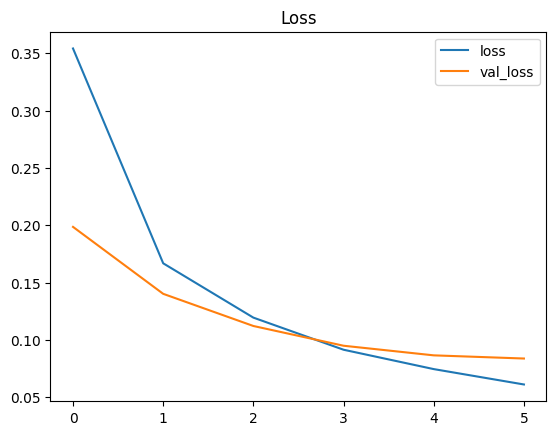

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

history_df = pd.DataFrame(history.history)

# Plot Loss
history_df.loc[:, ['loss', 'val_loss']].plot(title="Loss")

# Identify the accuracy keys dynamically
acc_key = 'accuracy' if 'accuracy' in history_df.columns else 'binary_accuracy'
val_acc_key = 'val_' + acc_key

if acc_key in history_df.columns:
    history_df.loc[:, [acc_key, val_acc_key]].plot(title="Accuracy")
    print(f"Max Validation Accuracy: {history_df[val_acc_key].max():.4f}")
else:
    print(f"Keys found in history: {list(history_df.columns)}")

print(f"Min Validation Loss: {history_df['val_loss'].min():.4f}")

In [11]:
print(history_df.columns)

Index(['loss', 'sparse_categorical_accuracy', 'val_loss',
       'val_sparse_categorical_accuracy'],
      dtype='object')
